Validation RF — MAE: 9.59, RMSE: 12.00
Validation XGB — MAE: 10.40, RMSE: 12.94
          Model    MAE_val   RMSE_val  RMSE_test
0  RandomForest   9.587320  11.995954  11.536292
1       XGBoost  10.399938  12.940858  11.653544


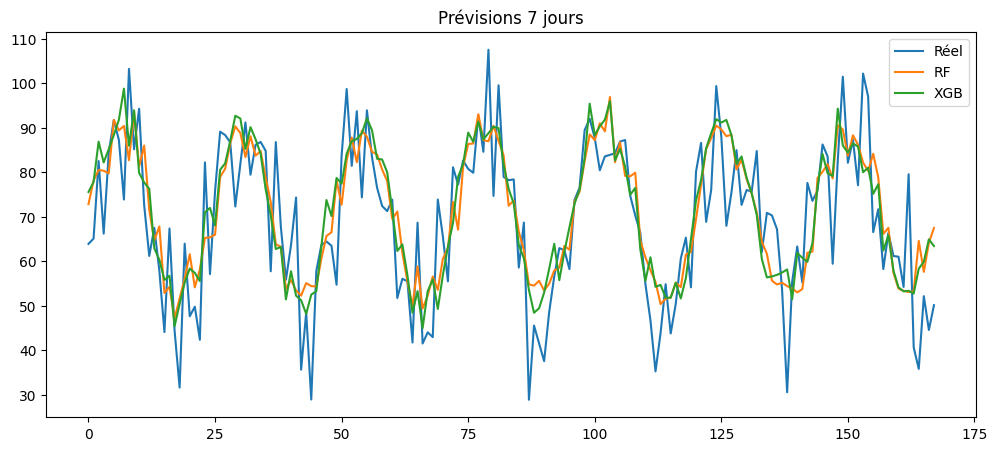

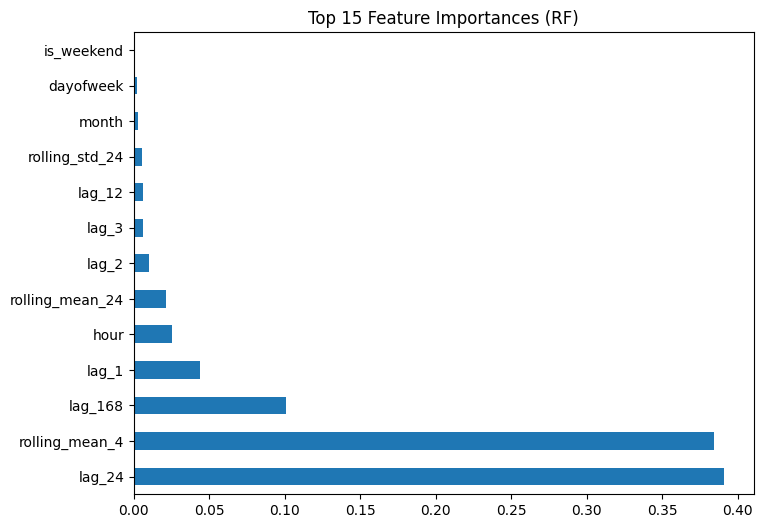

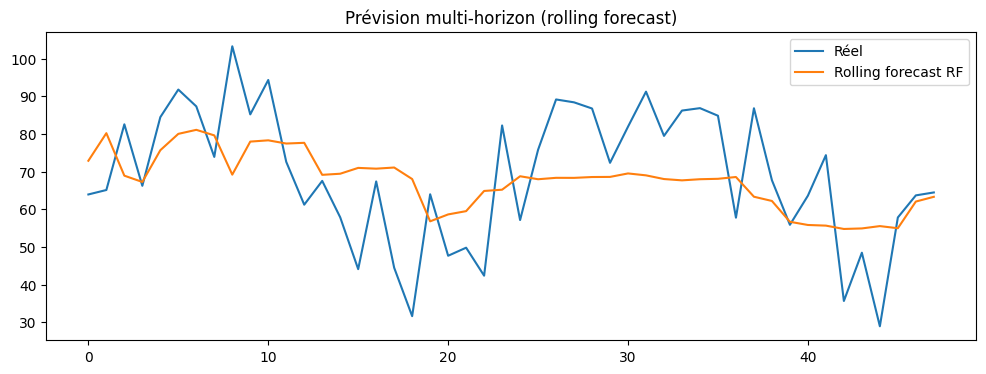

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor as XGBRegressor

df_features = serie.to_frame(name="count")

df_features["hour"] = df_features.index.hour
df_features["dayofweek"] = df_features.index.dayofweek
df_features["is_weekend"] = df_features["dayofweek"].isin([5,6]).astype(int)
df_features["month"] = df_features.index.month

for lag in [1,2,3,12,24,168]:
    df_features[f"lag_{lag}"] = df_features["count"].shift(lag)

df_features["rolling_mean_4"] = df_features["count"].shift(1).rolling(window=4).mean()
df_features["rolling_mean_24"] = df_features["count"].shift(1).rolling(window=24).mean()
df_features["rolling_std_24"] = df_features["count"].shift(1).rolling(window=24).std()

df_features = df_features.dropna()

X = df_features.drop(columns=["count"])
y = df_features["count"]

split_date = "2012-10-01"
split_index = X.index < split_date

X_train, X_test = X.loc[split_index], X.loc[~split_index]
y_train, y_test = y.loc[split_index], y.loc[~split_index]

tscv = TimeSeriesSplit(n_splits=5)

def evaluate_model(model):
    maes, rmses = [], []
    for train_idx, val_idx in tscv.split(X_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = model.predict(X_train.iloc[val_idx])
        maes.append(mean_absolute_error(y_train.iloc[val_idx], pred))
        rmses.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], pred)))  # sqrt(MSE)
    return np.mean(maes), np.mean(rmses)
    
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
mae_rf, rmse_rf = evaluate_model(rf)
print(f"Validation RF — MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, pred_rf))

try:
    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
except NameError:
    xgb = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

mae_xgb, rmse_xgb = evaluate_model(xgb)
print(f"Validation XGB — MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}")

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, pred_xgb))

metrics = pd.DataFrame({
    "Model": ["RandomForest", "XGBoost"],
    "MAE_val": [mae_rf, mae_xgb],
    "RMSE_val": [rmse_rf, rmse_xgb],
    "RMSE_test": [rmse_rf_test, rmse_xgb_test]
})
print(metrics)

plt.figure(figsize=(12,5))
plt.plot(y_test.iloc[:24*7].values, label="Réel")
plt.plot(pred_rf[:24*7], label="RF")
plt.plot(pred_xgb[:24*7], label="XGB")
plt.title("Prévisions 7 jours")
plt.legend()
plt.show()

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8,6))
plt.title("Top 15 Feature Importances (RF)")
plt.show()

def rolling_forecast(model, X_init, horizon):
    X_roll = X_init.copy()
    preds = []
    current_time = X_init.index[0]

    for h in range(horizon):
        y_pred = model.predict(X_roll)[0]
        preds.append(y_pred)

        current_time += pd.Timedelta(hours=1)
        X_roll["hour"] = current_time.hour
        X_roll["dayofweek"] = current_time.dayofweek
        X_roll["is_weekend"] = int(current_time.dayofweek >= 5)
        X_roll["month"] = current_time.month

        X_roll["lag_168"] = X_roll["lag_24"]
        X_roll["lag_24"]  = X_roll["lag_12"]
        X_roll["lag_12"]  = X_roll["lag_3"]
        X_roll["lag_3"]   = X_roll["lag_2"]
        X_roll["lag_2"]   = X_roll["lag_1"]
        X_roll["lag_1"]   = y_pred

    return preds

horizon = 48
preds_rolling = rolling_forecast(rf, X_test.iloc[[0]], horizon)

plt.figure(figsize=(12,4))
plt.plot(y_test.iloc[:horizon].values, label="Réel")
plt.plot(preds_rolling, label="Rolling forecast RF")
plt.title("Prévision multi-horizon (rolling forecast)")
plt.legend()
plt.show()
